# Curvature Exploration
**New notebook to explore different curvature definitions and their application to known datasets**

## 1. Imports

In [1037]:
# be sure to install the required libraries whathever .venv you're using
import sys

print(sys.executable)
!{sys.executable} -m pip3 install --upgrade pip
!{sys.executable} -m pip3 install networkx torch

/usr/local/bin/python3
/usr/local/bin/python3: No module named pip3
/usr/local/bin/python3: No module named pip3


In [1038]:
# system
import os

# standard data science libraries
import numpy as np
import pandas as pd

# plotting
import seaborn as sns
import networkx as nx

import matplotlib as mpl
from matplotlib import axes
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# core machine learning library
import torch

# utilities
from typing import Literal, List

# for Ollivier-Ricci curvature computation
from discrete_geometry_algos.ollivier_ricci import OllivierRicci

## 2. Selective data import & manipulation

In [1039]:
# parameters for data retrieval and model training
stalk_dim = 1
hidden_channels = 16
dataset = "synthetic_exp"
layers = 2
epochs = 500
fold = 0

# storing learned maps and laplacians from the experiments
maps, laplacians = [], []
for layer in range(layers):
    # load maps and laplacian for each provided layer
    maps_path = f"../results/maps/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/DiagSheaf_{dataset}_layer{layer}_fold{fold}_seed43.pt"
    laplacian_path = f"../results/laplacians/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/DiagSheaf_{dataset}_layer{layer}_fold{fold}_seed43.pt"
    maps.append(torch.load(maps_path))
    laplacians.append(torch.load(laplacian_path))

### 2.1 Maps

In [1040]:
# storing maps as pandas dataframes for easier analysis
maps_dfs = []
for map_item in maps:
    map_df = pd.DataFrame(map_item.cpu().tolist(), columns=["source", "target", "map_value"])
    map_df[["source", "target"]] = map_df[["source", "target"]].astype(int)
    map_df.sort_values(by=["source", "target"], ascending=[True, True], inplace=True)
    maps_dfs.append(map_df)

### 2.2 Laplacians

In [1041]:
# storing laplacians as pandas dataframes for easier analysis
# currently in source-, target- and value-rows format -> need to pivot
laplacians_dfs = []
for laplacian in laplacians:
    laplacian_df = pd.DataFrame(laplacian.cpu().tolist())
    laplacians_dfs.append(laplacian_df)

***l0 = node-level laplacian, l1 = edge-level laplacian***

here, we define lists for:
1. l0_list_paper: the 0-Laplacian as reconstructed from the paper's provided dataframes (pivoting the source-target-value format)
2. l0_list: the 0-Laplacian as computed from the incidence matrix (B @ B.T, as per Hodge)
3. l1_list: the 1-Laplacian as computed from the incidence matrix (B.T @ B, as per Hodge)
4. Incidence matrices

In [1042]:
l0_list_paper, l0_list, l1_list = [], [], []
incidence_matrices_list = []

# for 0-Laplacian as in the paper, we reconstruct the matrix by pivoting our current df
for lap in laplacians_dfs:
    df = lap.transpose().copy()
    df.rename(columns={0: "source", 1: "target", 2: "value"}, inplace=True)
    df_new = df.pivot(index="source", columns="target", values="value").fillna(0)
    l0 = df_new.to_numpy()
    l0_list_paper.append(l0)

# for 0-Laplacian, 1-Laplacian computed from scratch, we need maps matrix manipulation
for map_df in maps_dfs:
    
    df = map_df.copy()
    df[["source", "target"]] = df[["source", "target"]].astype(int)
    df["signed_map"] = np.where(df["target"] < df["source"], df["map_value"], -df["map_value"])

    df["edge"] = df.apply(lambda r: (min(r["source"], r["target"]), max(r["source"], r["target"])), axis=1)
    
    nodes = sorted(set(df["source"]).union(set(df["target"])))
    edges = sorted(set(df["edge"]))

    B = df.pivot(index="source", columns="edge", values="signed_map").fillna(0).to_numpy()
    B_pd = df.pivot(index="source", columns="edge", values="signed_map").fillna(0)
    
    # display(B_pd)

    incidence_matrices_list.append(B_pd)

    l0 = B @ B.T
    l0_list.append(l0)

    l1 = B.T @ B
    l1_list.append(l1)

### 2.3 Degree Matrices

#### 2.3.1 Standard Diagonal Matrices

In [1043]:
# the standard degree matrix D is a diagonal matrix where D[i,i] is the degree of node i
# which can be computed as the count of non-zero values of the entries in the corresponding row of B
D_standard = np.diag(np.count_nonzero(B, axis=1))
# display(D_standard)

# Augmented Standard Diagonal matrix D_tilde = D + I
D_standard_augmented = D_standard + np.eye(D_standard.shape[0])
# display(D_standard_augmented)

# Now we invert, in order to compute the actually used normalisation matrices D^{-1/2} and D^{-1}
# Base case
D_standard_inv = np.linalg.inv(D_standard)
D_standard_inv_sqrt = np.linalg.inv(np.sqrt(D_standard))

# Augmented case
D_standard_augmented_inv = np.linalg.inv(D_standard_augmented)
D_standard_augmented_inv_sqrt = np.linalg.inv(np.sqrt(D_standard_augmented))

# Apparently, we canm also avoid inverting the degree matrix and have a look as the node-enhanced version
# ie.: just conside the D_augmented as the matrix holding the weights for nodes

#### 2.3.2 Sheaf Diagonal Matrices

Sheaf Laplacian is an entry-wise defined matrix of the kind $(L_F)_{vv} = {\Sigma_{N(v)-nodes}} F^{T}_{v < e}F_{v < e}$

In [1044]:
# we use our maps-derived B matrices -> 0-L_F = B @ B.T -> use the diagonal entries as the D_sheaf
sheaf_D_dictionary = {}

sheaf_diag_matrices = []
sheaf_diag_matrices_augmented = []

sheaf_diag_matrices_inv = []
sheaf_diag_matrices_inv_sqrt = []

sheaf_diag_matrices_augmented_inv = []
sheaf_diag_matrices_augmented_inv_sqrt = []

# same computations as above, but for the sheaf-based Laplacian matrices, where the degree is computed from the maps-derived B matrices, layer by layer
for l0 in l0_list:
    D_sheaf = np.diag(l0)
    sheaf_diag_matrices.append(D_sheaf)
    # print("D_sheaf:\n", D_sheaf.shape)

    D_sheaf_augmented = D_sheaf + np.eye(D_sheaf.shape[0])
    sheaf_diag_matrices_augmented.append(D_sheaf_augmented)
    # print("D_sheaf_augmented:\n", D_sheaf_augmented.shape)

    D_sheaf_inv = np.linalg.inv(np.diag(D_sheaf))
    sheaf_diag_matrices_inv.append(D_sheaf_inv)
    # print("D_sheaf_inv:\n", D_sheaf_inv.shape)

    D_sheaf_inv_sqrt = np.linalg.inv(np.sqrt(np.diag(D_sheaf)))
    sheaf_diag_matrices_inv_sqrt.append(D_sheaf_inv_sqrt)
    # print("D_sheaf_inv_sqrt:\n", D_sheaf_inv_sqrt.shape)

    D_sheaf_augmented_inv = np.linalg.inv(D_sheaf_augmented)
    sheaf_diag_matrices_augmented_inv.append(D_sheaf_augmented_inv)
    # print("D_sheaf_augmented_inv:\n", D_sheaf_augmented_inv.shape)

    D_sheaf_augmented_inv_sqrt = np.linalg.inv(np.sqrt(D_sheaf_augmented))
    sheaf_diag_matrices_augmented_inv_sqrt.append(D_sheaf_augmented_inv_sqrt)
    # print("D_sheaf_augmented_inv_sqrt:\n", D_sheaf_augmented_inv_sqrt.shape)

# storing the computed sheaf matrices in a dictionary
sheaf_D_dictionary["sheaf_diag_matrices"] = sheaf_diag_matrices
sheaf_D_dictionary["sheaf_diag_matrices_augmented"] = sheaf_diag_matrices_augmented
sheaf_D_dictionary["sheaf_diag_matrices_inv"] = sheaf_diag_matrices_inv
sheaf_D_dictionary["sheaf_diag_matrices_inv_sqrt"] = sheaf_diag_matrices_inv_sqrt
sheaf_D_dictionary["sheaf_diag_matrices_augmented_inv"] = sheaf_diag_matrices_augmented_inv
sheaf_D_dictionary["sheaf_diag_matrices_augmented_inv_sqrt"] = sheaf_diag_matrices_augmented_inv_sqrt

In [1045]:
l0_list_paper[0][0,0]

0.11733768880367279

## 3. Curvature Computation

### 3.1 Bochner-Weitzenbock decomposition

In [1046]:
# formula to decompose the laplacian L into B + F:
# 1. B = combinatorial Bochner Laplacian (strongly non-negative)
# 2. F = combinatorial curvature term (diagonal matrix)

def fbc(L):
    
    l=L.shape[0]
    B=L.copy()
    
    for i in range(l):
        B[i,i]=np.sum(np.abs(L[i,:]))-np.abs(L[i,i])

    F = L - B
    
    return B , F

In [1047]:
# applying the BW decomposition to the laplacians, storing curvature terms
# curvature here is the combinatorial Ricci curvature, ie the diagonal F
# Ricci-curvature is only defined for edge-based Laplacians, otherwise it is an abuse of notation for k-combinatorial curvature term

fbc_curvature_paper_l0_list = [fbc(l0)[1] for l0 in l0_list_paper]
fbc_curvature_l0_list = [fbc(l0)[1] for l0 in l0_list]
fbc_curvature_l1_list = [fbc(l1)[1] for l1 in l1_list]

### 3.2 Forman-Weber Curvature Formula - first function attempt

![Curvature](../quick_analysis/images/ricci_weber_curvature.png)

In [1048]:
# first function, Laplacian may be selected at ease, doesn't rely on previously stored matrices
def forman_weber_curvature(L: np.ndarray, node_weight_mode: Literal["units", "nodes_degrees", "nodes_degrees_inverted", "laplacian_entries"] = "units") -> dict:
    
    """
    Compute the Forman-Weber curvature for a given Laplacian and incidence matrix.
    Inputs:
    - L: the Laplacian matrix, n x n np.ndarray
    - node_weight_mode: string, specifying the mode for computing node weights (default: "units")

    Outputs:
    - curvature_dict: dictionary w/ edge (input, output)-tuple keys, curvature values
    """
    
    # 1. edge-weights
    edge_weights = np.abs(L)

    # 2. node-weights
    if node_weight_mode == "nodes_degrees":

        # take the Laplacian matrix, compute degree matrix D
        # D + I augmentation is not needed, as the vv-entry is non-zero
        # then invert and take absolute values for node weights

        D = np.diag(np.count_nonzero(L, axis=1))
        node_weights = np.diag(D)

    elif node_weight_mode == "nodes_degrees_inverted":
        D = np.diag(np.count_nonzero(L, axis=1))
        node_weights = np.diag(np.linalg.inv(D))

    elif node_weight_mode == "laplacian_entries":
        node_weights = abs(np.diag(L))

    # print("edge weights:\n", edge_weights, "\n", "type:", type(edge_weights), "\n", "shape:", edge_weights.shape)
    # print("node weights:\n", node_weights, "\n", "type:", type(node_weights), "\n", "shape:", node_weights.shape)

    elif node_weight_mode == "units":
        node_weights = np.ones(L.shape[0])

    else:
        raise ValueError(f"Invalid node_weight_mode value: {node_weight_mode}. Expected one of 'units', 'nodes_degrees', 'nodes_degrees_inverted', 'laplacian_entries'.")

    # 3. curvature computation
    curvature_dict = {}
    for i in range(L.shape[0]):
        for j in range(L.shape[1]):
            if (i != j and L[i, j] != 0) and (i < j):
                edge_key = (i, j)

                # first term: weight(i) / weight(i,j)
                term1 = node_weights[i] / edge_weights[i, j]

                # second term: weight(j) / weight(i,j)
                term2 = node_weights[j] / edge_weights[i, j]

                # third term: sum_{over edges k incident to i} of weight of i / sqrt(weight(i,j) * weight(i,k))
                term3 = 0
                for k in range(L.shape[1]):
                    if k != j and L[i,k] != 0:
                        if i < k:
                            term3 += node_weights[i] / np.sqrt(edge_weights[i, j] * edge_weights[i, k])
                        else:
                            term3 += node_weights[i] / np.sqrt(edge_weights[i, j] * edge_weights[k, i])
                
                # fourth term: sum_{over edges k incident to j} of weight of j / sqrt(weight(i,j) * weight(j,k))
                term4 = 0
                for k in range(L.shape[1]):
                    if k != i and L[j,k] != 0:
                        if j < k:
                            term4 += node_weights[j] / np.sqrt(edge_weights[i, j] * edge_weights[j, k])
                        else:
                            term4 += node_weights[j] / np.sqrt(edge_weights[i, j] * edge_weights[k, j])

                # summing up the terms and multiplying by the edge weight
                # curvature_dict[edge_key] = (term1 + term2 - term3 - term4)
                curvature_dict[edge_key] = edge_weights[i, j] * (term1 + term2 - term3 - term4)
    
    return curvature_dict
    

#### 3.2.1 FW Curvature plotting

In [1049]:
# general parameters for the experiments
selected_layer = 0

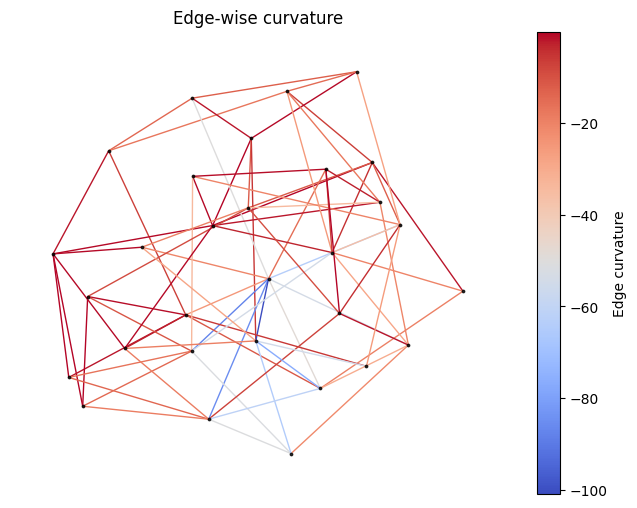

In [1050]:
# Idea 1
# Edge weights_{vu} := abs(uv-entry of the normalized Laplacian), ie.: the l0_paper uv-entry
# Node weights_{v} := abs(vv-entry of the normalized Laplacian), ie.: the l0_paper vv-entry

# plotting for a single-layer laplacian
curvature_dict_l0_paper = forman_weber_curvature(l0_list_paper[selected_layer], node_weight_mode="laplacian_entries")
# display(curvature_dict_l0_paper)

G = nx.Graph()
G.add_nodes_from(range(l0_list_paper[selected_layer].shape[0]))
G.add_edges_from(sorted(curvature_dict_l0_paper.keys()))

pos = nx.kamada_kawai_layout(G)  # for reproducible layout

edges = list(G.edges())
edge_colors = [
    curvature_dict_l0_paper[tuple(sorted(edge))]
    for edge in edges
]

vmin = np.min(edge_colors)
vmax = np.max(edge_colors)
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=(0 if (vmin < 0 < vmax) else (vmin+vmax)/2), vmax=vmax)
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(figsize=(8, 6))

nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=3, alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1, ax=ax)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Edge curvature")

ax.set_title("Edge-wise curvature")
ax.axis("off")
plt.show()

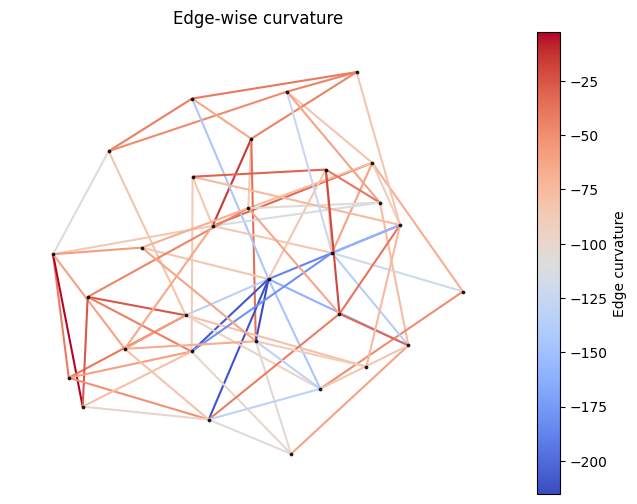

In [1051]:
# Idea 2
# Edge weights_{vu} := abs(uv-entry of the normalized Laplacian), ie.: the l0_paper uv-entry
# Node weights_{v} := abs(vv-entry of the augmented node's degree matrix ^{-1})

# plotting for a single-layer laplacian
curvature_dict_l0_paper = forman_weber_curvature(l0_list_paper[selected_layer], node_weight_mode="nodes_degrees")
# display(curvature_dict_l0_paper)

G = nx.Graph()
G.add_nodes_from(range(l0_list_paper[selected_layer].shape[0]))
G.add_edges_from(sorted(curvature_dict_l0_paper.keys()))

pos = nx.kamada_kawai_layout(G)  # for reproducible layout

edges = list(G.edges())
edge_colors = [
    curvature_dict_l0_paper[tuple(sorted(edge))]
    for edge in edges
]

vmin = np.min(edge_colors)
vmax = np.max(edge_colors)
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=(0 if (vmin < 0 < vmax) else (vmin+vmax)/2), vmax=vmax)
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(figsize=(8, 6))

nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=3, alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1.5, ax=ax)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Edge curvature")

ax.set_title("Edge-wise curvature")
ax.axis("off")
plt.show()

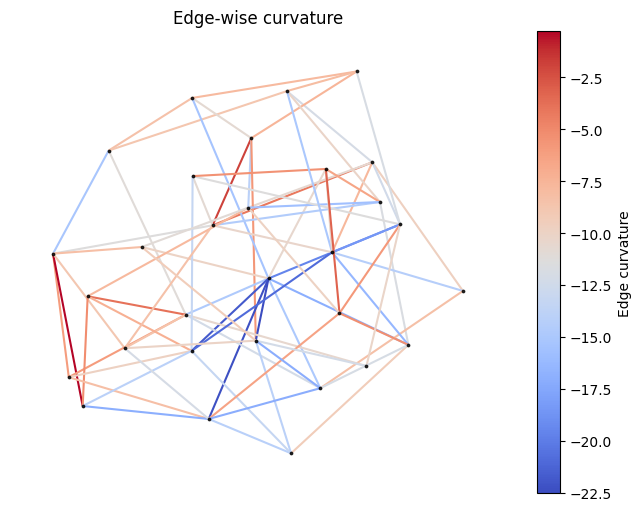

In [1052]:
# Idea 3
# Edge weights_{vu} := abs(uv-entry of the normalized Laplacian), ie.: the l0_paper uv-entry
# Node weights_{v} := identity matrix

# plotting for a single-layer laplacian
curvature_dict_l0_paper = forman_weber_curvature(l0_list_paper[selected_layer], node_weight_mode="units")
# display(curvature_dict_l0_paper)

G = nx.Graph()
G.add_nodes_from(range(l0_list_paper[selected_layer].shape[0]))
G.add_edges_from(sorted(curvature_dict_l0_paper.keys()))

pos = nx.kamada_kawai_layout(G)  # for reproducible layout

edges = list(G.edges())
edge_colors = [
    curvature_dict_l0_paper[tuple(sorted(edge))]
    for edge in edges
]

vmin = np.min(edge_colors)
vmax = np.max(edge_colors)
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=(0 if (vmin < 0 < vmax) else (vmin+vmax)/2), vmax=vmax)
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(figsize=(8, 6))

nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=3, alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1.5, ax=ax)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Edge curvature")

ax.set_title("Edge-wise curvature")
ax.axis("off")
plt.show()

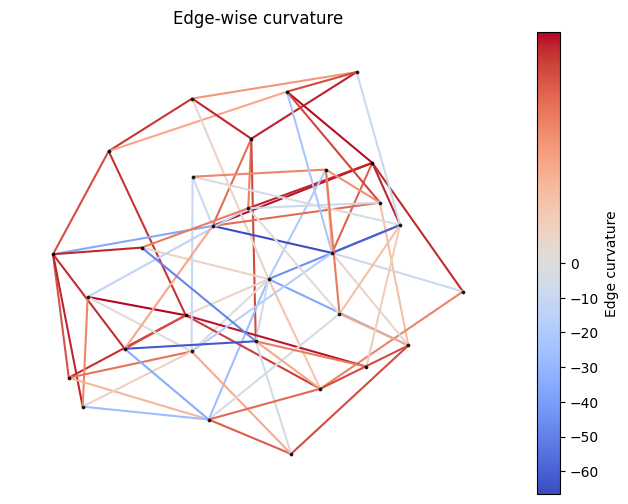

In [1053]:
# Idea 4
# Edge weights_{vu} := abs(uv-entry of the Laplacian), ie.: (our) l0 uv-entry
# Node weights_{v} := abs(vv-entry of our l0), ie.: (our) l0 vv-entry

# plotting for a single-layer laplacian
curvature_dict_l0 = forman_weber_curvature(l0_list[selected_layer], node_weight_mode="laplacian_entries")
# display(curvature_dict_l0)

G = nx.Graph()
G.add_nodes_from(range(l0_list[selected_layer].shape[0]))
G.add_edges_from(sorted(curvature_dict_l0.keys()))

pos = nx.kamada_kawai_layout(G)  # for reproducible layout

edges = list(G.edges())
edge_colors = [
    curvature_dict_l0[tuple(sorted(edge))]
    for edge in edges
]

vmin = np.min(edge_colors)
vmax = np.max(edge_colors)
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=(0 if (vmin < 0 < vmax) else (vmin+vmax)/2), vmax=vmax)
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(figsize=(8, 6))

nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=3, alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1.5, ax=ax)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Edge curvature")

ax.set_title("Edge-wise curvature")
ax.axis("off")
plt.show()

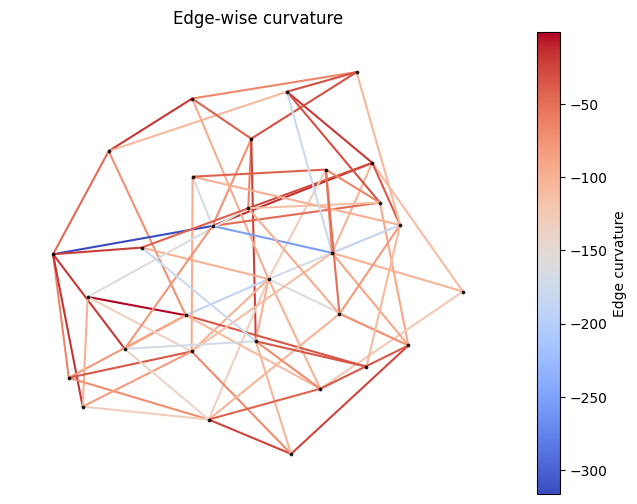

In [1054]:
# Idea 5
# Edge weights_{vu} := abs(uv-entry of the Laplacian), ie.: (our) l0 uv-entry
# Node weights_{v} := abs(vv-entry of the augmented node's degree matrix ^{-1})

# plotting for a single-layer laplacian
curvature_dict_l0 = forman_weber_curvature(l0_list[selected_layer], node_weight_mode="nodes_degrees")
# display(curvature_dict_l0)

G = nx.Graph()
G.add_nodes_from(list(range(l0_list[selected_layer].shape[0])))
G.add_edges_from(sorted(curvature_dict_l0.keys()))

pos = nx.kamada_kawai_layout(G)  # for reproducible layout

edges = list(G.edges())
edge_colors = [
    curvature_dict_l0[tuple(sorted(edge))]
    for edge in edges
]

vmin = np.min(edge_colors)
vmax = np.max(edge_colors)
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=(0 if (vmin < 0 < vmax) else (vmin+vmax)/2), vmax=vmax)
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(figsize=(8, 6))

nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=3, alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1.5, ax=ax)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Edge curvature")

ax.set_title("Edge-wise curvature")
ax.axis("off")
plt.show()

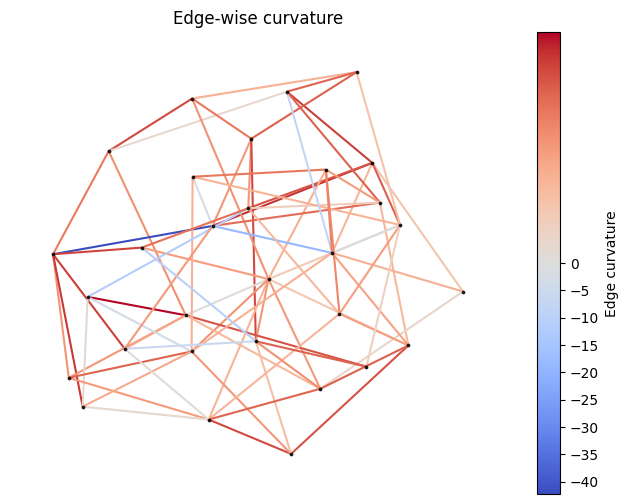

In [1055]:
# Idea 6
# Edge weights_{vu} := abs(uv-entry of the Laplacian), ie.: (our) l0 uv-entry
# Node weights_{v} := identity matrix

# plotting for a single-layer laplacian
curvature_dict_l0 = forman_weber_curvature(l0_list[selected_layer], node_weight_mode="units")
# display(curvature_dict_l0)

G = nx.Graph()
G.add_nodes_from(list(range(l0_list[selected_layer].shape[0])))
G.add_edges_from(sorted(curvature_dict_l0.keys()))

pos = nx.kamada_kawai_layout(G)  # for reproducible layout

edges = list(G.edges())
edge_colors = [
    curvature_dict_l0[tuple(sorted(edge))]
    for edge in edges
]

vmin = np.min(edge_colors)
vmax = np.max(edge_colors)
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=(0 if (vmin < 0 < vmax) else (vmin+vmax)/2), vmax=vmax)
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(figsize=(8, 6))

nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=3, alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1.5, ax=ax)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Edge curvature")

ax.set_title("Edge-wise curvature")
ax.axis("off")
plt.show()

#### 3.2.2 Multi-Layer Visual

In [1056]:
# we need to plot the curvature evolution across layers, given the laplacian and node-weights selection using the same hyper-parameters
selected_laplacian = l0_list
selected_node_weight_mode = "nodes_degrees_inverted"

##### 3.2.2.1 Only-Graphs Visual

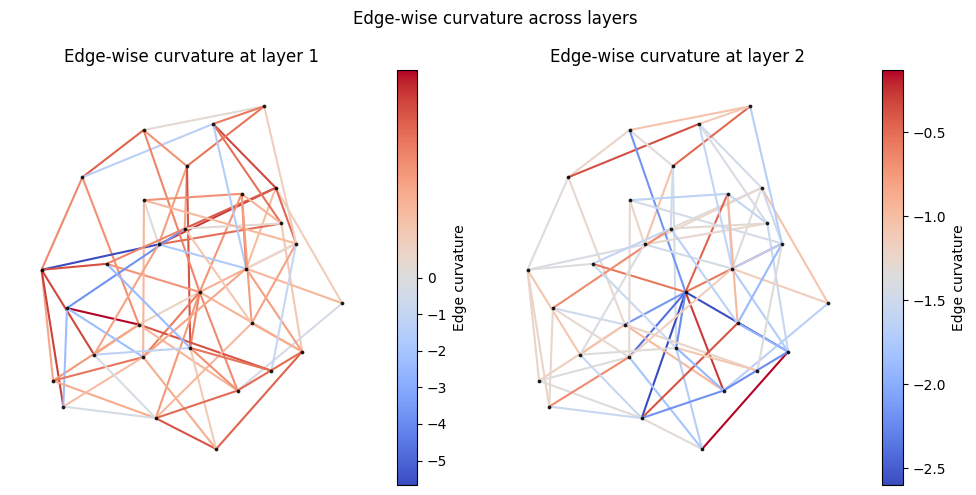

In [1057]:
fig, axes = plt.subplots(1, layers, figsize=(5 * layers, 5))

for layer in range(layers):
    curvature_dict_l0 = forman_weber_curvature(selected_laplacian[layer], node_weight_mode=selected_node_weight_mode)
    # display(curvature_dict_l0)
    
    G = nx.Graph()
    G.add_nodes_from(list(range(selected_laplacian[layer].shape[0])))
    G.add_edges_from(sorted(curvature_dict_l0.keys()))

    pos = nx.kamada_kawai_layout(G)  # for reproducible layout

    edges = list(G.edges())
    edge_colors = [
        curvature_dict_l0[tuple(sorted(edge))]
        for edge in edges]
    
    vmin = np.min(edge_colors)
    vmax = np.max(edge_colors)
    norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=(0 if (vmin < 0 < vmax) else (vmin+vmax)/2), vmax=vmax)
    cmap = plt.cm.coolwarm

    nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=3, alpha=0.8, ax=axes[layer])
    nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1.5, ax=axes[layer])

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=axes[layer])
    cbar.set_label("Edge curvature")

    axes[layer].set_title(f"Edge-wise curvature at layer {layer + 1}")
    axes[layer].axis("off")

plt.suptitle("Edge-wise curvature across layers")
plt.tight_layout()
plt.show()

##### 3.2.2.2 Graphs & Histograms Visual

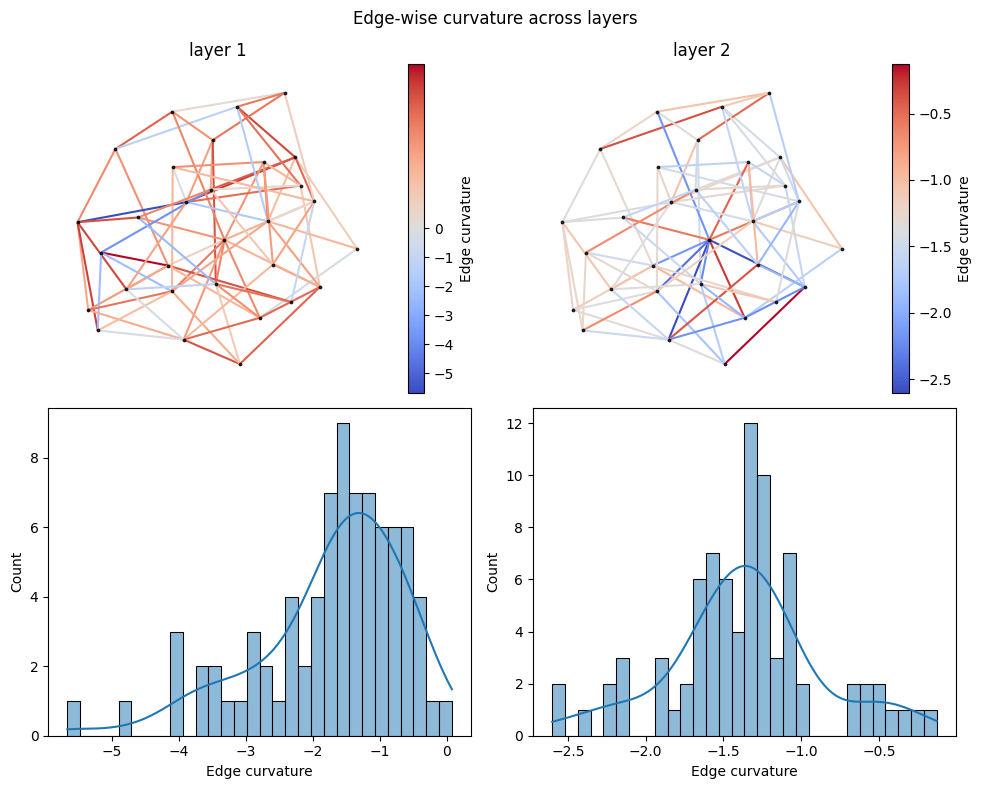

In [1058]:
fig, axes = plt.subplots(2, layers, figsize=(5 * layers, 8))

for layer in range(layers):
    
    # curvature computation
    curvature_dict_l0 = forman_weber_curvature(selected_laplacian[layer], node_weight_mode=selected_node_weight_mode)
    
    # graph construction
    G = nx.Graph()
    G.add_nodes_from(list(range(selected_laplacian[layer].shape[0])))
    G.add_edges_from(sorted(curvature_dict_l0.keys()))

    pos = nx.kamada_kawai_layout(G)  # for reproducible layout

    edges = list(G.edges())
    edge_colors = [
        curvature_dict_l0[tuple(sorted(edge))]
        for edge in edges]
    
    vmin = np.min(edge_colors)
    vmax = np.max(edge_colors)
    norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=(0 if (vmin < 0 < vmax) else (vmin+vmax)/2), vmax=vmax)
    cmap = plt.cm.coolwarm

    # row 1: curvature plot
    nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=3, alpha=0.8, ax=axes[0, layer])
    nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1.5, ax=axes[0, layer])

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=axes[0, layer])
    cbar.set_label("Edge curvature")

    axes[0, layer].set_title(f"layer {layer + 1}")
    axes[0, layer].axis("off")

    # row 2: curvature distribution
    curvature_values = list(curvature_dict_l0.values())
    sns.histplot(curvature_values, bins=30, kde=True, ax=axes[1, layer])
    axes[1, layer].set_xlabel("Edge curvature")
    # axes[1, layer].set_title(f"layer {layer + 1}")
    # axes[1, layer].set_ylabel("Frequency") 

plt.suptitle("Edge-wise curvature across layers")
plt.tight_layout()
plt.show()

## 4. Weights Exploration

### 4.1 Forman-Weber Curvature Formula - general function

In [1059]:
# Alternative curvature function, more general
def forman_weber_curvature_general(
        L: Literal["paper_Laplacian", "computed_Laplacian"] = "computed_Laplacian",
        layer_selection: int = 0,
        node_weight_mode: Literal[
            "units",
            "standard_nodes_degrees", "standard_nodes_degrees_inverted",
            "standard_nodes_degrees_augmented", "standard_nodes_degrees_augmented_inverted",
            "sheaf_nodes_degrees", "sheaf_nodes_degrees_inverted",
            "sheaf_nodes_degrees_augmented", "sheaf_nodes_degrees_augmented_inverted"
            ] = "units",
        output_weights_mode: bool = False):
    
    """
    Compute the Forman-Weber curvature for a given Laplacian and incidence matrix.
    Inputs:
    - L: Literal["paper Laplacian", "computed Laplacian"], whether to use the 0-Laplacian as provided in the paper or the one computed from the maps-derived B matrices (default: "computed Laplacian")
    - layer_selection: int, the layer to consider for curvature computation (default: 0)
    - node_weight_mode: the mode for computing node weights (default: "units")
    - output_weights_mode: whether to output just the computed node and edge weights along with the starting Laplacian (default: False)

    Outputs:

    if output_weights_mode is True (default):
    - L_0: the selected Laplacian matrix
    - edge_weights_dict: dictionary w/ edge (input, output)-tuple keys, edge weight values
    - node_weights: the computed node weights
    - edge_weights: the computed edge weights

    else:
    - L_0: the selected Laplacian matrix
    - curvature_dict: dictionary w/ edge (input, output)-tuple keys, curvature values
    - node_weights: the computed node weights
    - edge_weights: the computed edge weights
    """
    
    if L == "paper_Laplacian":
        L_0 = l0_list_paper[layer_selection]
        # print(L_0)

    elif L == "computed_Laplacian":
        L_0 = l0_list[layer_selection]
        # print(L_0)

    else:
        raise ValueError(f"Invalid L value: {L}. Expected one of 'paper_Laplacian', 'computed_Laplacian'.")
        
    # 1. edge-weights
    edge_weights = np.abs(L_0)

    # 2. node-weights
    if node_weight_mode == "units":
        node_weights = np.ones(L_0.shape[0])

    elif node_weight_mode == "standard_nodes_degrees":
        D = np.diag(np.count_nonzero(L_0, axis=1))
        node_weights = np.diag(D)

    elif node_weight_mode == "standard_nodes_degrees_inverted":
        D = np.diag(np.count_nonzero(L_0, axis=1))
        node_weights = np.diag(np.linalg.inv(D))

    elif node_weight_mode == "standard_nodes_degrees_augmented":
        D = np.diag(np.count_nonzero(L_0, axis=1))
        D = D + np.eye(D.shape[0])  # Add identity matrix for augmentation
        node_weights = np.diag(D)

    elif node_weight_mode == "standard_nodes_degrees_augmented_inverted":
        D = np.diag(np.count_nonzero(L_0, axis=1))
        D = D + np.eye(D.shape[0])  # Add identity matrix for augmentation
        node_weights = np.diag(np.linalg.inv(D))

    elif node_weight_mode == "sheaf_nodes_degrees":
        D = np.diag(L_0)
        node_weights = np.diag(D)

    elif node_weight_mode == "sheaf_nodes_degrees_inverted":
        D = np.diag(np.diag(L_0))
        display(D.shape)
        node_weights = np.diag(np.linalg.inv(D))
    
    elif node_weight_mode == "sheaf_nodes_degrees_augmented":
        D = np.diag(L_0)
        display(D.shape)
        D = D + np.eye(D.shape[0])  # Add identity matrix for augmentation
        display(D.shape)
        node_weights = np.diag(D)
    
    elif node_weight_mode == "sheaf_nodes_degrees_augmented_inverted":
        D = np.diag(L_0)
        display(D.shape)
        D = D + np.eye(D.shape[0])  # Add identity matrix for augmentation
        display(D.shape)

        node_weights = np.diag(np.linalg.inv(D))

    else:
        raise ValueError(f"Invalid node_weight_mode value: {node_weight_mode}")

    if output_weights_mode:
        
        edge_weights_dict = {(i, j): edge_weights[i, j] for i in range(L_0.shape[0]) for j in range(L_0.shape[1]) if (i != j and L_0[i, j] != 0) and (i < j)}
        
        return L_0, edge_weights_dict, node_weights, edge_weights
    
    else:
        # 3. curvature computation
        curvature_dict = {}
        for i in range(L_0.shape[0]):
            for j in range(L_0.shape[1]):
                if (i != j and L_0[i, j] != 0) and (i < j):
                    edge_key = (i, j)

                    # first term: weight(i) / weight(i,j)
                    term1 = node_weights[i] / edge_weights[i, j]

                    # second term: weight(j) / weight(i,j)
                    term2 = node_weights[j] / edge_weights[i, j]

                    # third term: sum_{over edges k incident to i} of weight of i / sqrt(weight(i,j) * weight(i,k))
                    term3 = 0
                    for k in range(L_0.shape[1]):
                        if k != j and L_0[i,k] != 0:
                            if i < k:
                                term3 += node_weights[i] / np.sqrt(edge_weights[i, j] * edge_weights[i, k])
                            elif i > k:
                                term3 += node_weights[i] / np.sqrt(edge_weights[i, j] * edge_weights[k, i])
                    
                    # fourth term: sum_{over edges k incident to j} of weight of j / sqrt(weight(i,j) * weight(j,k))
                    term4 = 0
                    for k in range(L_0.shape[1]):
                        if k != i and L_0[j,k] != 0:
                            if j < k:
                                term4 += node_weights[j] / np.sqrt(edge_weights[i, j] * edge_weights[j, k])
                            elif j > k:
                                term4 += node_weights[j] / np.sqrt(edge_weights[i, j] * edge_weights[k, j])

                    # summing up the terms and multiplying by the edge weight
                    # curvature_dict[edge_key] = (term1 + term2 - term3 - term4)
                    curvature_dict[edge_key] = edge_weights[i, j] * (term1 + term2 - term3 - term4)
        
        return L_0, curvature_dict, node_weights, edge_weights

### 4.2 New Curvature/Weights Plotting

#### 4.2.1 Single Experiments

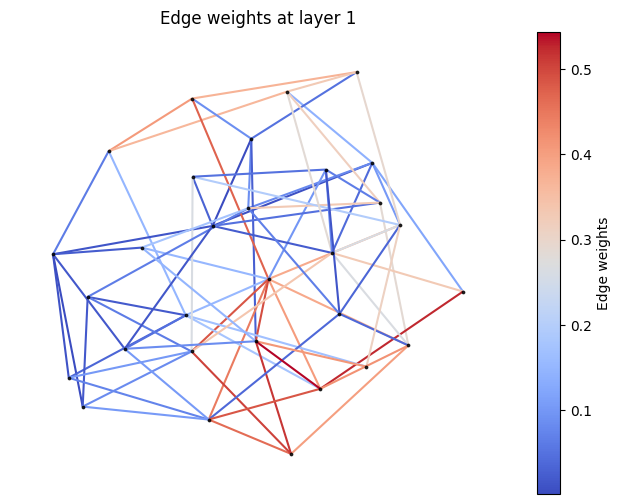

In [1060]:
# selected layer for curvature computation
selected_layer = 0

# general curvature function - B @ B.T Laplacian - compute_weights mode
L_0, edge_weights_dict, node_weights, edge_weights = forman_weber_curvature_general(
    L = "paper_Laplacian",
    layer_selection=selected_layer,
    node_weight_mode="units",
    output_weights_mode=True
    )

# entry-level visuals
G = nx.Graph()
G.add_nodes_from(list(range(L_0.shape[0])))
G.add_edges_from(sorted(edge_weights_dict.keys()))

pos = nx.kamada_kawai_layout(G)
edges = list(G.edges())
edge_colors = [
    edge_weights_dict[tuple(sorted(edge))] for edge in edges
]

cmap = plt.cm.coolwarm

fig, ax = plt.subplots(figsize=(8, 6))
nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=3, alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, width=1.5, ax=ax)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(edge_colors), vmax=max(edge_colors)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Edge weights")
ax.set_title(f"Edge weights at layer {selected_layer + 1}")
ax.axis("off")
plt.show()

#### 4.2.2 layer-by-layer visuals

In [1061]:
# edge weights for all layers, stored in a dictionary for easier access
edge_weights_layer_dict = {layer_selection: forman_weber_curvature_general(layer_selection=layer_selection, output_weights_mode=True)[1] for layer_selection in range(layers)}

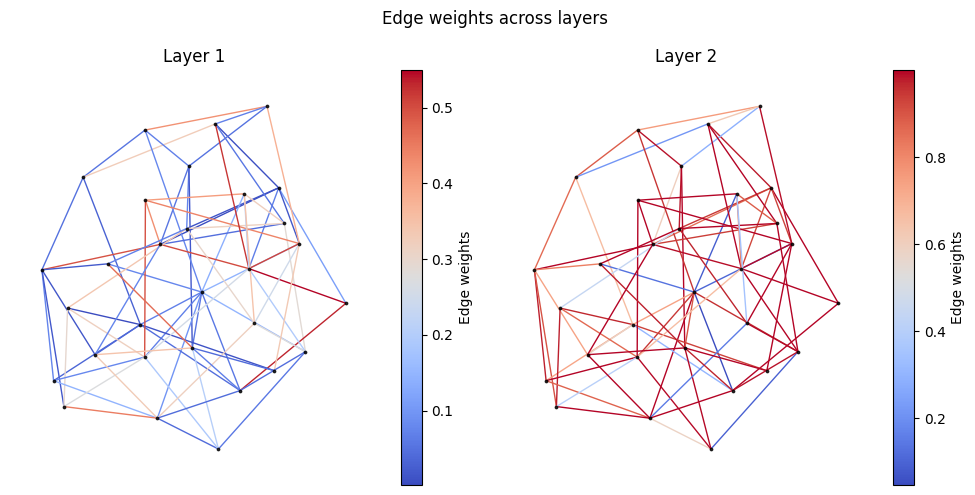

In [1062]:
# plotting edge weights across layers - just graph visualisation
fig, axes = plt.subplots(1, layers, figsize=(5 * layers, 5))

for layer in range(layers):
    edge_weights_dict = edge_weights_layer_dict[layer]
    
    G = nx.Graph()
    G.add_nodes_from(list(range(L_0.shape[0])))
    G.add_edges_from(sorted(edge_weights_dict.keys()))

    pos = nx.kamada_kawai_layout(G)

    edges = list(G.edges())
    edge_colors = [
        edge_weights_dict[tuple(sorted(edge))] for edge in edges
    ]

    vmin = np.min(edge_colors)
    vmax = np.max(edge_colors)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.coolwarm

    nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=3, alpha=0.8, ax=axes[layer])
    nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1, ax=axes[layer])

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=axes[layer])
    cbar.set_label("Edge weights")

    axes[layer].set_title(f"Layer {layer + 1}")
    axes[layer].axis("off")
plt.suptitle("Edge weights across layers")
plt.tight_layout()
plt.show()

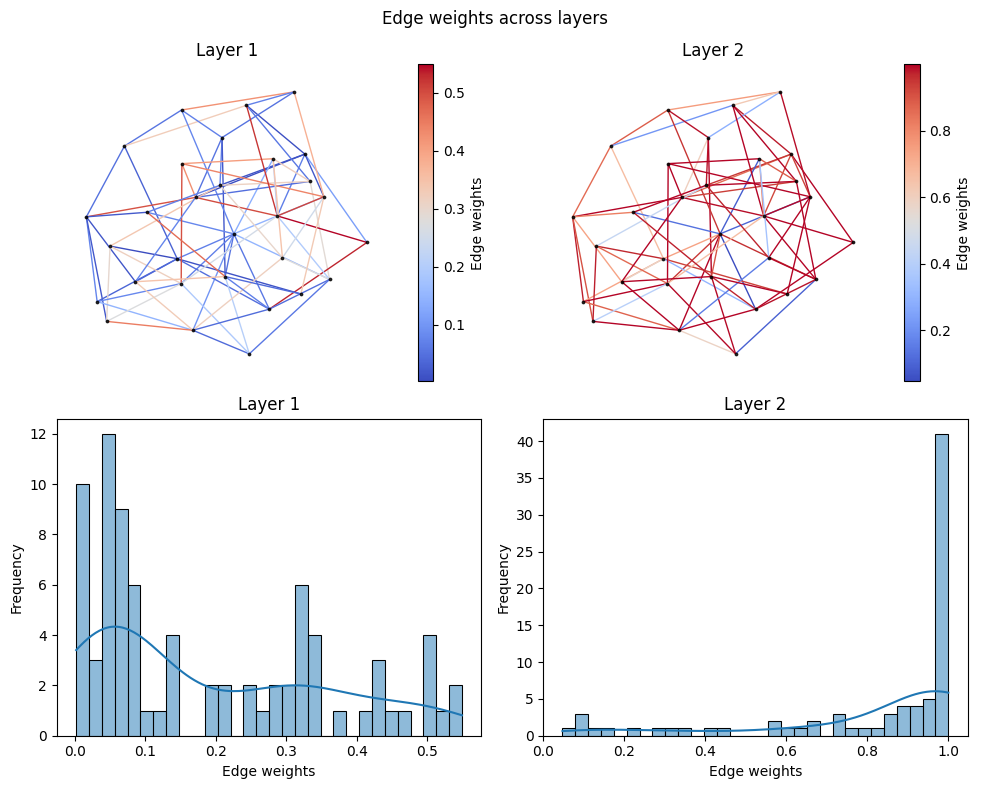

In [1063]:
# plotting edge weights across layers - graph visualisation + distribution
fig, axes = plt.subplots(2, layers, figsize=(5 * layers, 8))

for layer in range(layers):
    
    edge_weights_dict = edge_weights_layer_dict[layer]
    
    G = nx.Graph()
    G.add_nodes_from(list(range(L_0.shape[0])))
    G.add_edges_from(sorted(edge_weights_dict.keys()))

    pos = nx.kamada_kawai_layout(G)

    edges = list(G.edges())
    edge_colors = [
        edge_weights_dict[tuple(sorted(edge))] for edge in edges
    ]

    vmin = np.min(edge_colors)
    vmax = np.max(edge_colors)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.coolwarm

    # row 1: edge weights plot
    nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=3, alpha=0.8, ax=axes[0, layer])
    nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1, ax=axes[0, layer])

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=axes[0, layer])
    cbar.set_label("Edge weights")

    axes[0, layer].set_title(f"Layer {layer + 1}")
    axes[0, layer].axis("off")

    # row 2: edge weights distribution
    edge_weight_values = list(edge_weights_dict.values())
    sns.histplot(edge_weight_values, bins=30, kde=True, ax=axes[1, layer])
    axes[1, layer].set_xlabel("Edge weights")
    axes[1, layer].set_title(f"Layer {layer + 1}")
    axes[1, layer].set_ylabel("Frequency")

plt.suptitle("Edge weights across layers")
plt.tight_layout()
plt.show()

#### 4.2.3 Normalised VS Non-normalised Laplacian edge-weights

In [1064]:
# edge weights for all layers, stored in a dictionary for easier access
unnorm_edge_weights_layer_dict = {layer_selection: forman_weber_curvature_general(L="computed_Laplacian", layer_selection=layer_selection, output_weights_mode=True)[1] for layer_selection in range(layers)}
norm_edge_weights_layer_dict = {layer_selection: forman_weber_curvature_general(L="paper_Laplacian", layer_selection=layer_selection, output_weights_mode=True)[1] for layer_selection in range(layers)}

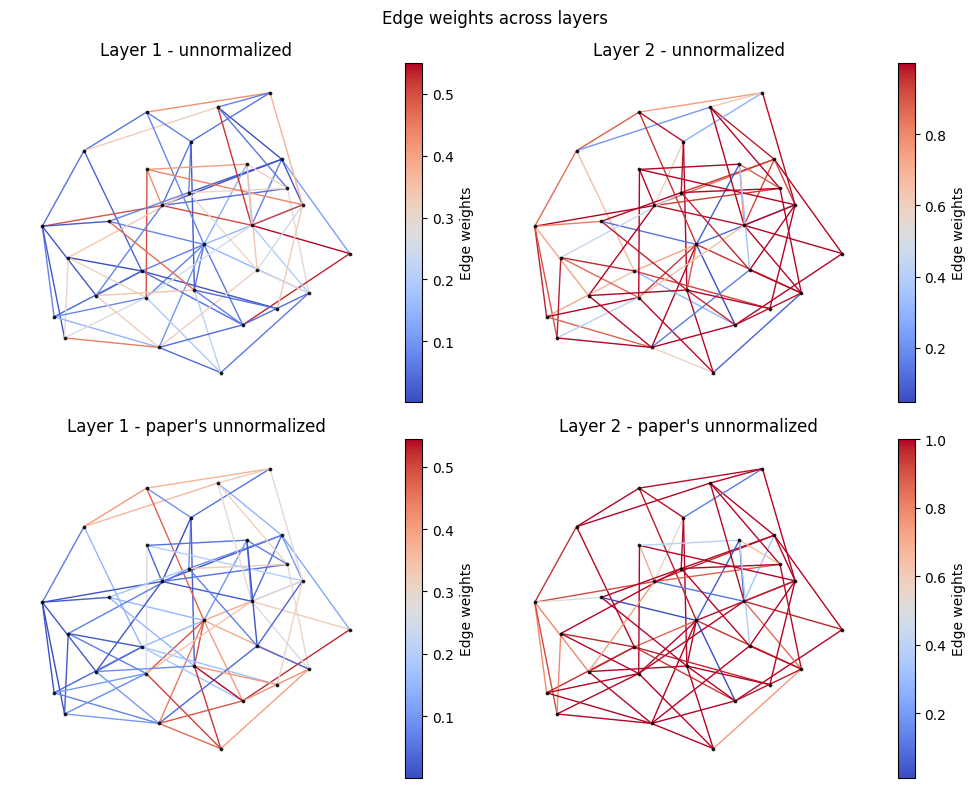

In [1065]:
# we're interested in comparing edge-weight distribution across layers, given two different Laplacian selections
# 1. unnormalized Laplacian (our B @ B.T, w/ B = maps-incidence matrix)
# 2. normalized Laplacian (the one provided in the paper, which is a normalization of the kind L = (D + eye)^{-1/2} @ B @ B.T @ (D + eye)^{-1/2})

fig, axes = plt.subplots(2, layers, figsize=(5 * layers, 8))

for layer in range(layers):
    
    # 1. unnormalized edge weights
    edge_weights_dict = unnorm_edge_weights_layer_dict[layer]
    
    G = nx.Graph()
    G.add_nodes_from(list(range(L_0.shape[0])))
    G.add_edges_from(sorted(edge_weights_dict.keys()))

    pos = nx.kamada_kawai_layout(G)

    edges = list(G.edges())
    edge_colors = [
        edge_weights_dict[tuple(sorted(edge))] for edge in edges
    ]

    vmin = np.min(edge_colors)
    vmax = np.max(edge_colors)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.coolwarm

    nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=3, alpha=0.8, ax=axes[0, layer])
    nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1, ax=axes[0, layer])

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=axes[0, layer])
    cbar.set_label("Edge weights")

    axes[0, layer].set_title(f"Layer {layer + 1} - unnormalized")
    axes[0, layer].axis("off")

    # 2. normalized edge weights
    edge_weights_dict = norm_edge_weights_layer_dict[layer]

    G = nx.Graph()
    G.add_nodes_from(list(range(L_0.shape[0])))
    G.add_edges_from(sorted(edge_weights_dict.keys()))

    pos = nx.kamada_kawai_layout(G)

    edges = list(G.edges())
    edge_colors = [
        edge_weights_dict[tuple(sorted(edge))] for edge in edges
    ]

    vmin = np.min(edge_colors)
    vmax = np.max(edge_colors)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.coolwarm

    nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=3, alpha=0.8, ax=axes[1, layer])
    nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1, ax=axes[1, layer])

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=axes[1, layer])
    cbar.set_label("Edge weights")

    axes[1, layer].set_title(f"Layer {layer + 1} - paper's unnormalized")
    axes[1, layer].axis("off")

plt.suptitle("Edge weights across layers")
plt.tight_layout()
plt.show()

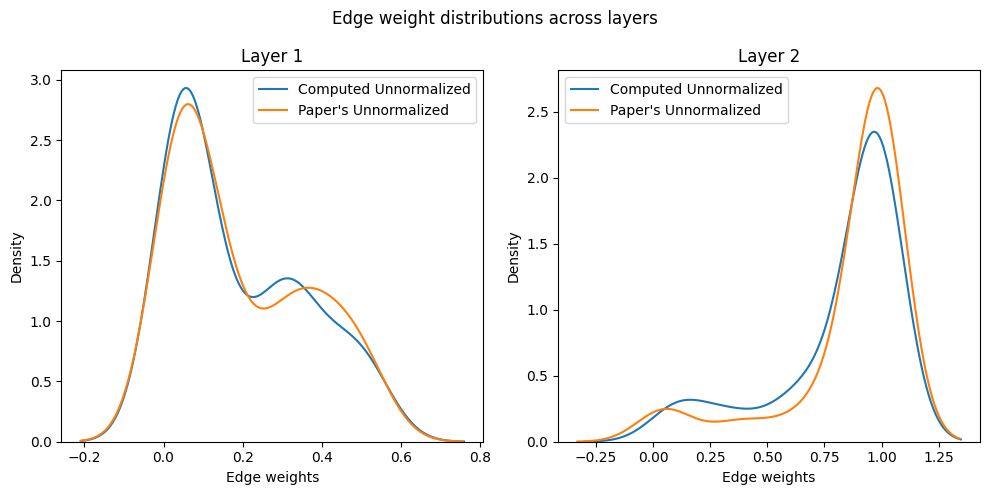

In [1066]:
# plotting unnormalized vs normalized edge weights for all layers - distribution comparison
fig, axes = plt.subplots(1, layers, figsize=(5 * layers, 5))

for layer in range(layers):
    
    # unnormalized edge weights
    edge_weights_dict = unnorm_edge_weights_layer_dict[layer]
    edge_weight_values_unnorm = list(edge_weights_dict.values())
    
    # normalized edge weights
    edge_weights_dict = norm_edge_weights_layer_dict[layer]
    edge_weight_values_norm = list(edge_weights_dict.values())
    
    sns.kdeplot(edge_weight_values_unnorm, label="Computed Unnormalized", ax=axes[layer])
    sns.kdeplot(edge_weight_values_norm, label="Paper's Unnormalized", ax=axes[layer])
    
    axes[layer].set_title(f"Layer {layer + 1}")
    axes[layer].set_xlabel("Edge weights")
    axes[layer].set_ylabel("Density")
    axes[layer].legend()
plt.suptitle("Edge weight distributions across layers")
plt.tight_layout()
plt.show()

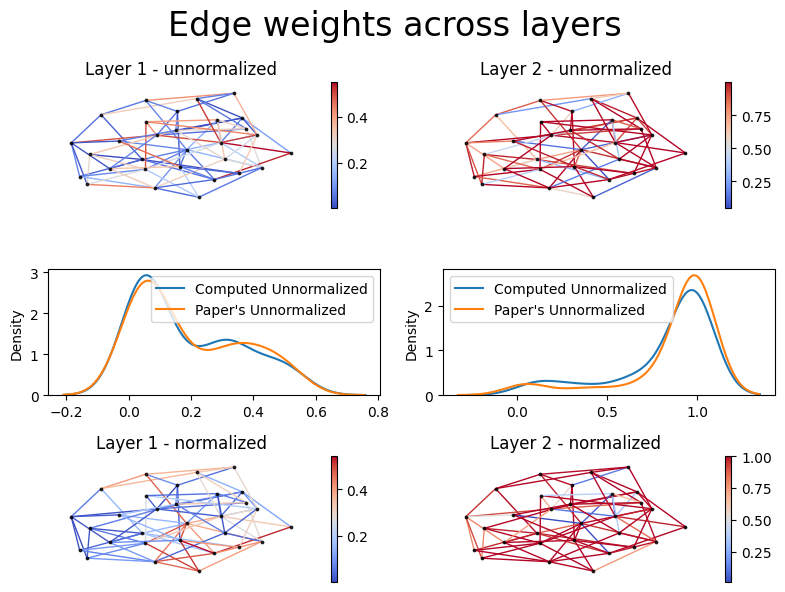

In [1067]:
# complete edge weights graph visual + density comparison
fig, axes = plt.subplots(3, layers, figsize=(4 * layers, 3 * layers))
# fig, axes = plt.subplots(3, layers)

for layer in range(layers):
    
    # 1. unnormalized edge weights
    edge_weights_dict = unnorm_edge_weights_layer_dict[layer]
    
    G = nx.Graph()
    G.add_nodes_from(list(range(L_0.shape[0])))
    G.add_edges_from(sorted(edge_weights_dict.keys()))

    pos = nx.kamada_kawai_layout(G)

    edges = list(G.edges())
    edge_colors = [
        edge_weights_dict[tuple(sorted(edge))] for edge in edges
    ]

    vmin = np.min(edge_colors)
    vmax = np.max(edge_colors)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.coolwarm

    nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=3, alpha=0.8, ax=axes[0, layer])
    nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1, ax=axes[0, layer])

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=axes[0, layer])
    # cbar.set_label("Edge weights")

    axes[0, layer].set_title(f"Layer {layer + 1} - unnormalized")
    axes[0, layer].axis("off")

    # 2. normalized edge weights
    edge_weights_dict = norm_edge_weights_layer_dict[layer]

    G = nx.Graph()
    G.add_nodes_from(list(range(L_0.shape[0])))
    G.add_edges_from(sorted(edge_weights_dict.keys()))

    pos = nx.kamada_kawai_layout(G)

    edges = list(G.edges())
    edge_colors = [
        edge_weights_dict[tuple(sorted(edge))] for edge in edges
    ]

    vmin = np.min(edge_colors)
    vmax = np.max(edge_colors)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.coolwarm

    nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=3, alpha=0.8, ax=axes[2, layer])
    nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1, ax=axes[2 , layer])

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=axes[2, layer])
    # cbar.set_label("Edge weights")

    axes[2, layer].set_title(f"Layer {layer + 1} - normalized")
    axes[2, layer].axis("off")

    # 3. unnormalized vs normalized edge weights distribution comparison
    
    # unnormalized edge weights
    edge_weights_dict = unnorm_edge_weights_layer_dict[layer]
    edge_weight_values_unnorm = list(edge_weights_dict.values())
    
    # normalized edge weights
    edge_weights_dict = norm_edge_weights_layer_dict[layer]
    edge_weight_values_norm = list(edge_weights_dict.values())
    
    sns.kdeplot(edge_weight_values_unnorm, label="Computed Unnormalized", ax=axes[1, layer])
    sns.kdeplot(edge_weight_values_norm, label="Paper's Unnormalized", ax=axes[1, layer])
    
    # axes[1, layer].set_title(f"Layer {layer + 1}")
    # axes[1, layer].set_xlabel("Edge weights")
    # axes[1, layer].set_ylabel("Density")
    axes[1, layer].legend()

plt.suptitle("Edge weights across layers", fontsize=24)
plt.tight_layout()
plt.show()

### 4.3 Multi-dataset comparison

In [1068]:
# various datasets imports
# parameters for data retrieval and model training
stalk_dim = 1
hidden_channels = 16
# dataset_list = ["texas", "cornell", "wisconsin", "cora", "synthetic_exp"]
dataset_list = ["synthetic_exp"] # exclude cora for timing purposes
layers = 2
epochs = 500
fold = 0

# storing learned maps and laplacians from the experiments

dataset_general_dict = {dataset: {} for dataset in dataset_list}

# basic loop to load the maps and laplacians for each dataset and layer, given the same hyper-parameters (stalk_dim, hidden_channels, layers, epochs, fold)
for dataset in dataset_list:
    maps, laplacians = [], []
    for layer in range(layers):
    # load maps and laplacian for each provided layer
        maps_path = f"../results/maps/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/DiagSheaf_{dataset}_layer{layer}_fold{fold}_seed43.pt"
        laplacian_path = f"../results/laplacians/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/DiagSheaf_{dataset}_layer{layer}_fold{fold}_seed43.pt"
        maps.append(torch.load(maps_path))
        laplacians.append(torch.load(laplacian_path))
    dataset_general_dict[dataset]["maps"] = maps
    dataset_general_dict[dataset]["laplacians"] = laplacians  

# modified maps storing
for dataset in dataset_list:
    maps_dfs = []
    for map_item in dataset_general_dict[dataset]["maps"]:
        map_df = pd.DataFrame(map_item.cpu().tolist(), columns=["source", "target", "map_value"])
        map_df[["source", "target"]] = map_df[["source", "target"]].astype(int)
        map_df.sort_values(by=["source", "target"], ascending=[True, True], inplace=True)
        maps_dfs.append(map_df)
    dataset_general_dict[dataset]["maps_dataframes"] = maps_dfs

# modified laplacians storing
for dataset in dataset_list:
    laplacians_dfs = []
    for laplacian_item in dataset_general_dict[dataset]["laplacians"]:
        # print(f"Loading laplacian for {dataset}: {laplacian_item}")
        laplacian_df = pd.DataFrame(laplacian_item.cpu().tolist())
        laplacians_dfs.append(laplacian_df)
    dataset_general_dict[dataset]["laplacians_dataframes"] = laplacians_dfs

# normalized and unnormalized laplacians storing
for dataset in dataset_list:
    
    maps_dfs = dataset_general_dict[dataset]["maps_dataframes"]
    laplacians_dfs = dataset_general_dict[dataset]["laplacians_dataframes"]
    
    l0_list_paper, l0_list = [], []

    # for 0-Laplacian as in the paper, we reconstruct the matrix by pivoting our current df
    for lap in laplacians_dfs:
        df = lap.transpose().copy()
        df.rename(columns={0: "source", 1: "target", 2: "value"}, inplace=True)
        df_new = df.pivot(index="source", columns="target", values="value").fillna(0)
        l0 = df_new.to_numpy()
        l0_list_paper.append(l0)

    # for 0-Laplacian computed from scratch, we need maps matrix manipulation
    for map_df in maps_dfs:
        
        df = map_df.copy()
        df[["source", "target"]] = df[["source", "target"]].astype(int)
        df["signed_map"] = np.where(df["target"] < df["source"], df["map_value"], -df["map_value"])

        df["edge"] = df.apply(lambda r: (min(r["source"], r["target"]), max(r["source"], r["target"])), axis=1)
        
        nodes = sorted(set(df["source"]).union(set(df["target"])))
        edges = sorted(set(df["edge"]))

        B = df.pivot(index="source", columns="edge", values="signed_map").fillna(0).to_numpy()
        # B_pd = df.pivot(index="source", columns="edge", values="signed_map").fillna(0)
        
        l0 = B @ B.T
        l0_list.append(l0)

    dataset_general_dict[dataset]["l0_list_norm"] = l0_list_paper
    dataset_general_dict[dataset]["l0_list_unnorm"] = l0_list

In [1069]:
# updated function for edge weights and curvatures - slightly different, takes into account different dataframes selections
def forman_weber_curvature_general(
        L: Literal["paper_Laplacian", "computed_Laplacian"] = "computed_Laplacian",
        dataset: str = "texas",
        layer_selection: int = 0,
        node_weight_mode: Literal[
            "units",
            "standard_nodes_degrees", "standard_nodes_degrees_inverted",
            "standard_nodes_degrees_augmented", "standard_nodes_degrees_augmented_inverted",
            "sheaf_nodes_degrees", "sheaf_nodes_degrees_inverted",
            "sheaf_nodes_degrees_augmented", "sheaf_nodes_degrees_augmented_inverted"
            ] = "units",
        output_weights_mode: bool = False):
    
    """
    Compute the Forman-Weber curvature for a given Laplacian and incidence matrix.
    Inputs:
    - L: Literal["paper Laplacian", "computed Laplacian"], whether to use the 0-Laplacian as provided in the paper or the one computed from the maps-derived B matrices (default: "computed Laplacian")
    - dataset: str, the dataset to consider for curvature computation (default: "texas")
    - layer_selection: int, the layer to consider for curvature computation (default: 0)
    - node_weight_mode: the mode for computing node weights (default: "units")
    - output_weights_mode: whether to output just the computed node and edge weights along with the starting Laplacian (default: False)

    Outputs:

    if output_weights_mode is True (default):
    - L_0: the selected Laplacian matrix
    - edge_weights_dict: dictionary w/ edge (input, output)-tuple keys, edge weight values
    - node_weights: the computed node weights
    - edge_weights: the computed edge weights

    else:
    - L_0: the selected Laplacian matrix
    - curvature_dict: dictionary w/ edge (input, output)-tuple keys, curvature values
    - node_weights: the computed node weights
    - edge_weights: the computed edge weights
    """
    
    if L == "paper_Laplacian":
        L_0 = dataset_general_dict[dataset]["l0_list_norm"][layer_selection]

    elif L == "computed_Laplacian":
        L_0 = dataset_general_dict[dataset]["l0_list_unnorm"][layer_selection]

    else:
        raise ValueError(f"Invalid L value: {L}. Expected one of 'paper_Laplacian', 'computed_Laplacian'.")
        
    # 1. edge-weights
    edge_weights = np.abs(L_0)

    # 2. node-weights
    if node_weight_mode == "units":
        node_weights = np.ones(L_0.shape[0])

    elif node_weight_mode == "standard_nodes_degrees":
        D = np.diag(np.count_nonzero(L_0, axis=1))
        node_weights = np.diag(D)

    elif node_weight_mode == "standard_nodes_degrees_inverted":
        D = np.diag(np.count_nonzero(L_0, axis=1))
        node_weights = np.diag(np.linalg.inv(D))

    elif node_weight_mode == "standard_nodes_degrees_augmented":
        D = np.diag(np.count_nonzero(L_0, axis=1))
        D = D + np.eye(D.shape[0])  # Add identity matrix for augmentation
        node_weights = np.diag(D)

    elif node_weight_mode == "standard_nodes_degrees_augmented_inverted":
        D = np.diag(np.count_nonzero(L_0, axis=1))
        D = D + np.eye(D.shape[0])  # Add identity matrix for augmentation
        node_weights = np.diag(np.linalg.inv(D))

    elif node_weight_mode == "sheaf_nodes_degrees":
        D = np.diag(L_0)
        node_weights = np.diag(D)

    elif node_weight_mode == "sheaf_nodes_degrees_inverted":
        D = np.diag(np.diag(L_0))
        display(D.shape)
        node_weights = np.diag(np.linalg.inv(D))
    
    elif node_weight_mode == "sheaf_nodes_degrees_augmented":
        D = np.diag(L_0)
        display(D.shape)
        D = D + np.eye(D.shape[0])  # Add identity matrix for augmentation
        display(D.shape)
        node_weights = np.diag(D)
    
    elif node_weight_mode == "sheaf_nodes_degrees_augmented_inverted":
        D = np.diag(L_0)
        display(D.shape)
        D = D + np.eye(D.shape[0])  # Add identity matrix for augmentation
        display(D.shape)

        node_weights = np.diag(np.linalg.inv(D))

    else:
        raise ValueError(f"Invalid node_weight_mode value: {node_weight_mode}")

    if output_weights_mode:
        
        edge_weights_dict = {(i, j): edge_weights[i, j] for i in range(L_0.shape[0]) for j in range(L_0.shape[1]) if (i != j and L_0[i, j] != 0) and (i < j)}
        
        return L_0, edge_weights_dict, node_weights, edge_weights
    
    else:
        # 3. curvature computation
        curvature_dict = {}
        for i in range(L_0.shape[0]):
            for j in range(L_0.shape[1]):
                if (i != j and L_0[i, j] != 0) and (i < j):
                    edge_key = (i, j)

                    # first term: weight(i) / weight(i,j)
                    term1 = node_weights[i] / edge_weights[i, j]

                    # second term: weight(j) / weight(i,j)
                    term2 = node_weights[j] / edge_weights[i, j]

                    # third term: sum_{over edges k incident to i} of weight of i / sqrt(weight(i,j) * weight(i,k))
                    term3 = 0
                    for k in range(L_0.shape[1]):
                        if k != j and L_0[i,k] != 0:
                            if i < k:
                                term3 += node_weights[i] / np.sqrt(edge_weights[i, j] * edge_weights[i, k])
                            elif i > k:
                                term3 += node_weights[i] / np.sqrt(edge_weights[i, j] * edge_weights[k, i])
                    
                    # fourth term: sum_{over edges k incident to j} of weight of j / sqrt(weight(i,j) * weight(j,k))
                    term4 = 0
                    for k in range(L_0.shape[1]):
                        if k != i and L_0[j,k] != 0:
                            if j < k:
                                term4 += node_weights[j] / np.sqrt(edge_weights[i, j] * edge_weights[j, k])
                            elif j > k:
                                term4 += node_weights[j] / np.sqrt(edge_weights[i, j] * edge_weights[k, j])

                    # summing up the terms and multiplying by the edge weight
                    # curvature_dict[edge_key] = (term1 + term2 - term3 - term4)
                    curvature_dict[edge_key] = edge_weights[i, j] * (term1 + term2 - term3 - term4)
        
        return L_0, curvature_dict, node_weights, edge_weights

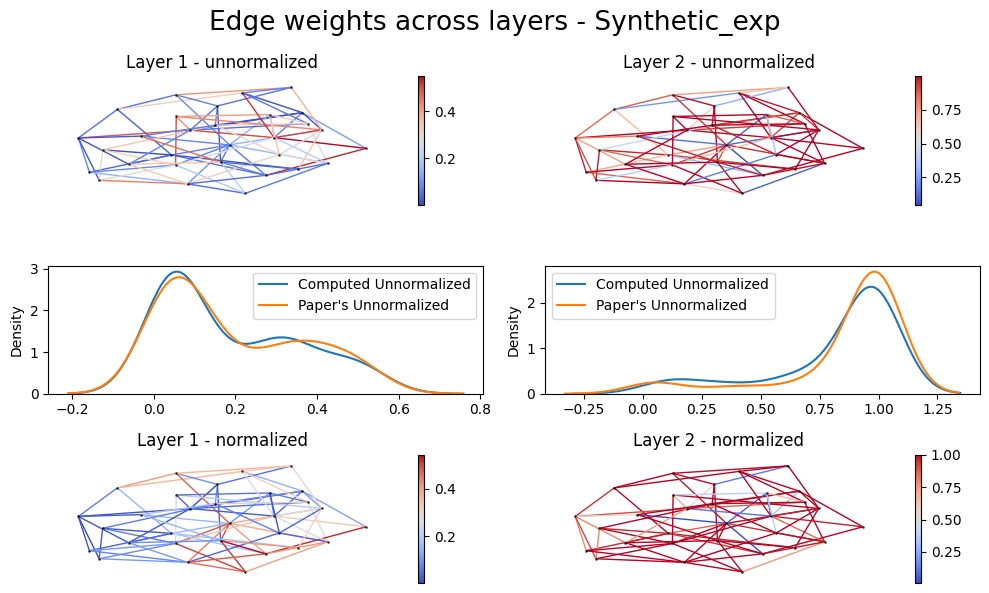

In [1070]:
# plotting, for each dataset, the edge weights, subdividing:
# - by layer
# - by Laplacian selection (normalized vs unnormalized)
# - by visualization type (graph visualisation vs distribution comparison)
for dataset in dataset_list:
    
    unnorm_edge_weights_layer_dict = {layer_selection: forman_weber_curvature_general(L="computed_Laplacian", dataset=dataset, layer_selection=layer_selection, output_weights_mode=True)[1] for layer_selection in range(layers)}
    norm_edge_weights_layer_dict = {layer_selection: forman_weber_curvature_general(L="paper_Laplacian", dataset=dataset, layer_selection=layer_selection, output_weights_mode=True)[1] for layer_selection in range(layers)}

    fig, axes = plt.subplots(3, layers, figsize=(5 * layers, 3 * layers))
    # fig, axes = plt.subplots(3, layers)

    for layer in range(layers):
        
        # 1. unnormalized edge weights
        edge_weights_dict = unnorm_edge_weights_layer_dict[layer]
        
        nodes = sorted(set([node for edge in edge_weights_dict.keys() for node in edge]))

        G = nx.Graph()
        G.add_nodes_from(nodes)
        G.add_edges_from(sorted(edge_weights_dict.keys()))

        pos = nx.kamada_kawai_layout(G)

        edges = list(G.edges())
        edge_colors = [
            edge_weights_dict[tuple(sorted(edge))] for edge in edges
        ]

        vmin = np.min(edge_colors)
        vmax = np.max(edge_colors)
        norm = plt.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.cm.coolwarm

        nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=1, alpha=0.6, ax=axes[0, layer])
        nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1, ax=axes[0, layer])

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])

        cbar = plt.colorbar(sm, ax=axes[0, layer])

        axes[0, layer].set_title(f"Layer {layer + 1} - unnormalized")
        axes[0, layer].axis("off")

        # 2. normalized edge weights
        edge_weights_dict = norm_edge_weights_layer_dict[layer]

        nodes = sorted(set([node for edge in edge_weights_dict.keys() for node in edge]))

        G = nx.Graph()
        G.add_nodes_from(nodes)
        G.add_edges_from(sorted(edge_weights_dict.keys()))

        pos = nx.kamada_kawai_layout(G)
        edges = list(G.edges())
        edge_colors = [
            edge_weights_dict[tuple(sorted(edge))] for edge in edges
        ]

        vmin = np.min(edge_colors)
        vmax = np.max(edge_colors)
        norm = plt.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.cm.coolwarm

        nx.draw_networkx_nodes(G, pos=pos, node_color='black', node_size=1, alpha=0.6, ax=axes[2, layer])
        nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color=edge_colors, edge_cmap=cmap, edge_vmin=vmin, edge_vmax=vmax, width=1, ax=axes[2 , layer])
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=axes[2, layer])
        # cbar.set_label("Edge weights")
        axes[2, layer].set_title(f"Layer {layer + 1} - normalized")
        axes[2, layer].axis("off")

        # 3. unnormalized vs normalized edge weights distribution comparison
        
        # unnormalized edge weights
        edge_weights_dict = unnorm_edge_weights_layer_dict[layer]
        edge_weight_values_unnorm = list(edge_weights_dict.values())
        
        # normalized edge weights
        edge_weights_dict = norm_edge_weights_layer_dict[layer]
        edge_weight_values_norm = list(edge_weights_dict.values())
        sns.kdeplot(edge_weight_values_unnorm, label="Computed Unnormalized", ax=axes[1, layer])
        sns.kdeplot(edge_weight_values_norm, label="Paper's Unnormalized", ax=axes[1, layer])
        axes[1, layer].legend()
    
    plt.suptitle(f"Edge weights across layers - {dataset.capitalize()}", fontsize=19)
    plt.tight_layout()
    plt.show()

## 5. New Curvature Attempt: Ollivier-Ricci

- our previous attempt was w/ Weber-style curvature -> move on to Ollivier-Ricci, from scratch, trying to follow the paper "OLLIVIER RICCI-FLOW ON WEIGHTED GRAPHS" (by Bai, Lin et al)
- the main reference is the formula in Definition #3 in the paper, hereby reported

![Ollivier-Ricci-Curvature](../quick_analysis/images/ollivier_ricci_curvature.png)

- Intuitively, given G = (V,E):
1. we define probability measures on nodes x,y in V ie.: \mu_x and \mu_y
2. define a coupling A: V x V -> [0,1] that needs to sum up to \mu_x and \mu_y respectively
3. W(\mu_x, \mu_y) comes from minimizing the moving cost between \mu_x and \mu_y over a choice of such coupling A
4. W < standard d(x,y) implies positive curvature, W > standard d(x,y) implies negative curvature
- that's basically analoguous to what happens in the standard Riemmanian manifold context, as we're comparing the actual x-y distance over the open-balls B_x, B_y geodesic-implied one

### 5.1 Patrick R. Nicolas GitHub implementation

The following code implementation comes from the GitHub of Patrick R. Nicolas

In [1071]:
# example dataset data - use Texas or something small for easier visualization and testing
dataset = "synthetic_exp"
layer_selection = 0

laplacian, edge_weights_dict, _ , _ =  forman_weber_curvature_general(L="paper_Laplacian", dataset=dataset, layer_selection=layer_selection, output_weights_mode=True)

# for the OR curvature as delivered by the imported code, weights need to be arranged as follows:
# - edge_weights = torch.Tensor
# - edge_index = List[Tuple[int, int]] (sorted by source node, then target node)
edge_index = sorted(list(edge_weights_dict.keys()))
edge_weights = torch.tensor(list(edge_weights_dict.values()))

In [1072]:
# implementation of the OR curvature computation, given the edge weights and edge index as delivered by the forman_weber_curvature_general function
ollivier_ricci = OllivierRicci(
    edge_index=edge_index,
    weights=edge_weights,
    epsilon=0.001,
    rc=None
)

curvature = ollivier_ricci.curvature(n_iters=1000, early_stop_threshold=0.0001)
display(curvature.shape)

discrete_curvature_dict = {(i, j): float(curvature[i, j]) for i in range(curvature.shape[0]) for j in range(curvature.shape[1]) if (i != j and curvature[i, j] != 0) and (i < j)}
display(discrete_curvature_dict)

torch.Size([30, 30])

{(0, 5): 0.8408035039901733,
 (0, 11): 0.3337172865867615,
 (0, 15): 0.8623210191726685,
 (0, 16): -2.0699315071105957,
 (0, 21): 0.8121145367622375,
 (0, 24): 0.7579322457313538,
 (1, 6): 0.6936684846878052,
 (1, 7): 0.8092669248580933,
 (1, 9): 0.8833826184272766,
 (1, 15): 0.9132030606269836,
 (2, 9): 0.7776231169700623,
 (2, 16): -5.846797466278076,
 (2, 24): 0.7805445790290833,
 (2, 28): 0.2684020400047302,
 (2, 29): 0.6062679886817932,
 (3, 7): 0.8753555417060852,
 (3, 9): 0.9280120134353638,
 (3, 17): 0.9418138265609741,
 (3, 19): 0.8732689023017883,
 (3, 21): 0.8688873052597046,
 (3, 23): 0.8054739832878113,
 (3, 25): 0.8705660104751587,
 (3, 26): 0.8710084557533264,
 (3, 27): 0.9187023043632507,
 (3, 28): 0.9070736765861511,
 (4, 15): 0.9008800983428955,
 (4, 16): 0.5999643802642822,
 (4, 23): 0.7012695670127869,
 (4, 24): 0.8562514781951904,
 (4, 25): 0.8314439654350281,
 (5, 11): 0.871505081653595,
 (5, 17): 0.9457019567489624,
 (6, 16): -0.497699499130249,
 (6, 18): -0.5895

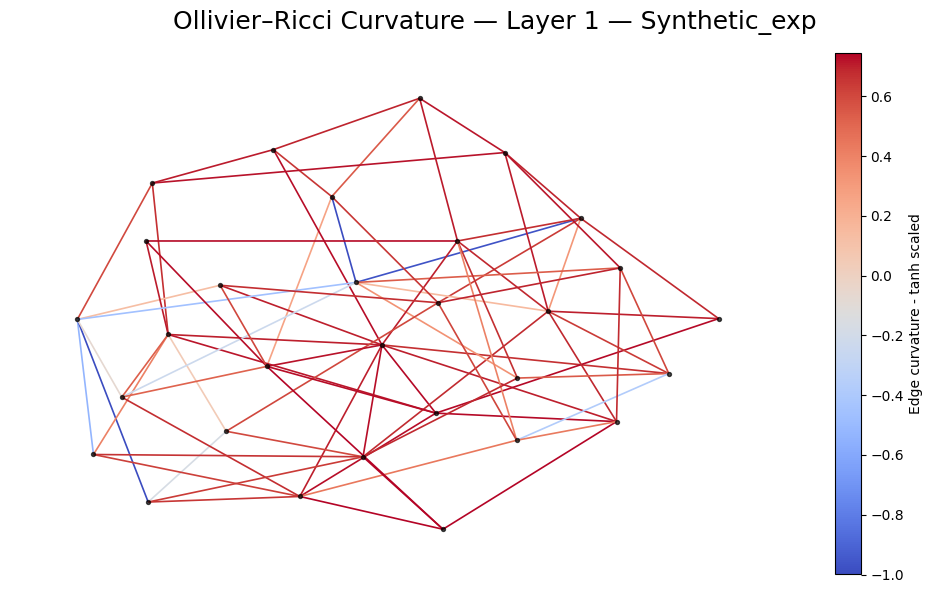

In [1073]:
G = nx.Graph()
G.add_edges_from(discrete_curvature_dict.keys())

# Layout uses topology only
pos = nx.kamada_kawai_layout(G)
edges = list(sorted(G.edges()))
weights = np.tanh(np.array([discrete_curvature_dict[tuple(sorted((u, v)))]for u, v in edges]))

fig, ax = plt.subplots(figsize=(10, 6))

nx.draw_networkx_nodes(
    G, pos,
    node_color="black",
    node_size=8,
    alpha=0.7,
    ax=ax
)

nx.draw_networkx_edges(
    G, pos,
    edgelist=edges,
    edge_color=weights,
    edge_cmap=plt.cm.coolwarm,
    width=1.2,
    ax=ax
)

sm = plt.cm.ScalarMappable(
    cmap=plt.cm.coolwarm,
    norm=plt.Normalize(vmin=weights.min(), vmax=weights.max())
)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Edge curvature - tanh scaled")

# ax.set_title(f"Ollivier–Ricci Cuzrvature — Layer {layer_selection + 1} — {dataset.capitalize()}")
ax.axis("off")

plt.suptitle(f"Ollivier–Ricci Curvature — Layer {layer_selection + 1} — {dataset.capitalize()}", fontsize=18)
plt.tight_layout()
plt.show()

#### 5.1.1 Enhanced Visuals

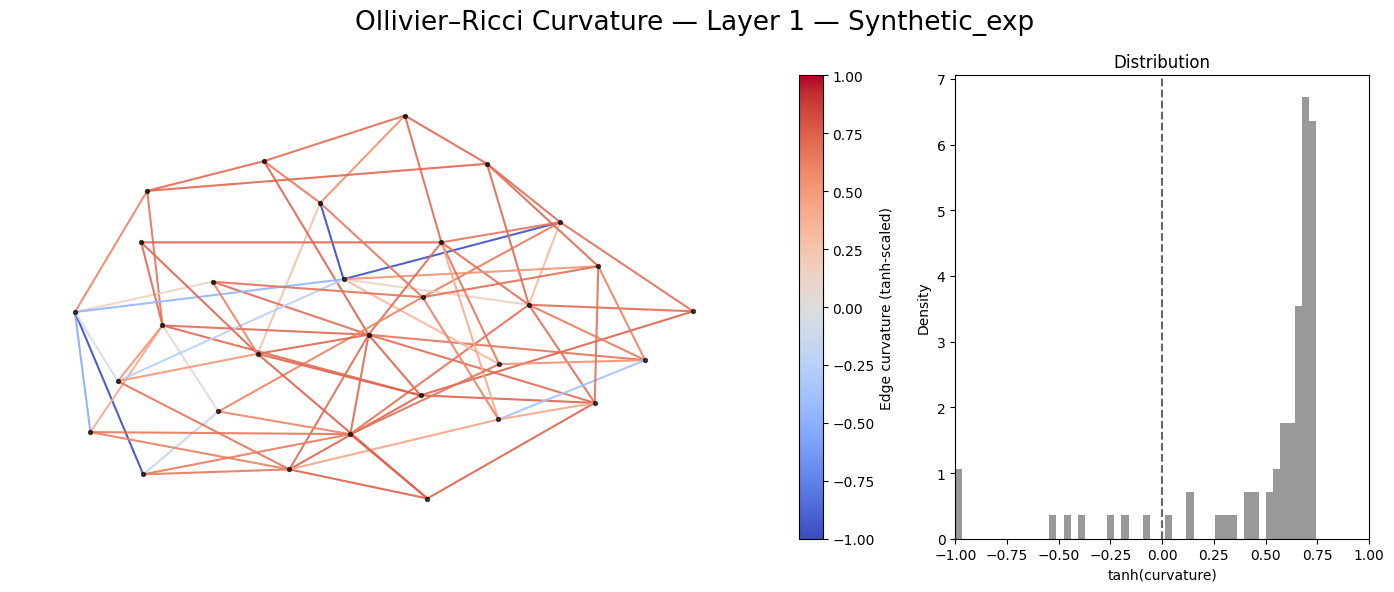

In [1074]:
# --- Build graph ---
G = nx.Graph()

# normalize keys once
G.add_edges_from(discrete_curvature_dict.keys())

pos = nx.kamada_kawai_layout(G)

edges = sorted(G.edges())
raw_weights = np.array([discrete_curvature_dict[tuple(sorted((u, v)))]for u, v in edges])
weights = np.tanh(raw_weights)

# --- Figure with 2 panels ---
fig, (ax_graph, ax_hist) = plt.subplots(
    1, 2, figsize=(14, 6),
    gridspec_kw={"width_ratios": [2, 1]}
)

# =======================
# GRAPH (left)
# =======================
norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

nx.draw_networkx_nodes(
    G, pos,
    node_color="black",
    node_size=8,
    alpha=0.7,
    ax=ax_graph
)

nx.draw_networkx_edges(
    G, pos,
    edgelist=edges,
    edge_color=weights,
    edge_cmap=plt.cm.coolwarm,
    edge_vmin=-1,
    edge_vmax=1,
    width=1.5,
    alpha=0.9,
    ax=ax_graph
)

sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, norm=norm)
sm.set_array([])

fig.colorbar(sm, ax=ax_graph, fraction=0.046, label="Edge curvature (tanh-scaled)")
ax_graph.axis("off")

# =======================
# HISTOGRAM (right)
# =======================
ax_hist.hist(weights, bins=50, density=True, alpha=0.8, color="gray")

# zero line
ax_hist.axvline(0, linestyle="--", color="black", alpha=0.6)

ax_hist.set_xlabel("tanh(curvature)")
ax_hist.set_ylabel("Density")
ax_hist.set_title("Distribution")

# optional: match x-limits to color scale
ax_hist.set_xlim(-1, 1)

plt.suptitle(f"Ollivier–Ricci Curvature — Layer {layer_selection + 1} — {dataset.capitalize()}", fontsize=19)
plt.tight_layout()
plt.show()

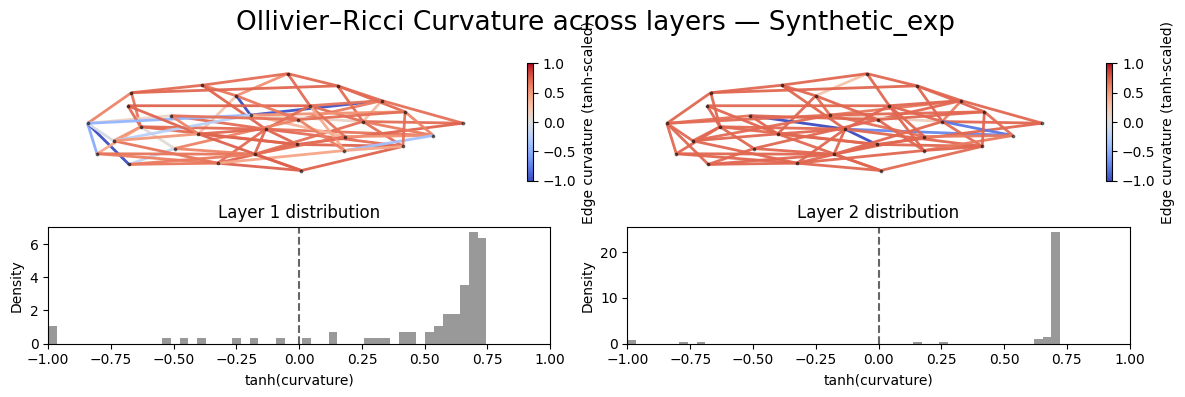

In [1075]:
# layer-by-layer graph + distribution visual for the selected dataset, with Ollivier–Ricci curvature as edge weights
fig, axes = plt.subplots(2, layers, figsize=(6 * layers, 2 * layers))

for layer in range(layers):
    
    laplacian, edge_weights_dict, _ , _ =  forman_weber_curvature_general(L="paper_Laplacian", dataset=dataset, layer_selection=layer, output_weights_mode=True)

    edge_index = sorted(list(edge_weights_dict.keys()))
    edge_weights = torch.tensor(list(edge_weights_dict.values()))

    ollivier_ricci = OllivierRicci(
        edge_index=edge_index,
        weights=edge_weights,
        epsilon=0.001,
        rc=None
    )

    curvature = ollivier_ricci.curvature(n_iters=1000, early_stop_threshold=0.0001)
    discrete_curvature_dict = {(i, j): float(curvature[i, j]) for i in range(curvature.shape[0]) for j in range(curvature.shape[1]) if (i != j and curvature[i, j] != 0) and (i < j)}

    G = nx.Graph()
    G.add_edges_from(discrete_curvature_dict.keys())

    pos = nx.kamada_kawai_layout(G)
    edges = list(sorted(G.edges()))
    weights = np.tanh(np.array([discrete_curvature_dict[tuple(sorted((u, v)))]for u, v in edges]))

    norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    nx.draw_networkx_nodes(
        G, pos,
        node_color="black",
        node_size=3,
        alpha=0.5,
        ax=axes[0, layer]
    )

    nx.draw_networkx_edges(
        G, pos,
        edgelist=edges,
        edge_color=weights,
        edge_cmap=plt.cm.coolwarm,
        edge_vmin=-1,
        edge_vmax=1,
        width=2,
        alpha=0.95,
        ax=axes[0, layer]
    )

    sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, norm=norm)
    sm.set_array([])

    fig.colorbar(sm, ax=axes[0, layer], fraction=0.046, label="Edge curvature (tanh-scaled)")
    axes[0, layer].axis("off")

    # =======================
    # HISTOGRAM (right)
    # =======================
    axes[1, layer].hist(weights, bins=50, density=True, alpha=0.8, color="gray")
    axes[1, layer].axvline(0, linestyle="--", color="black", alpha=0.6)
    axes[1, layer].set_xlabel("tanh(curvature)")
    axes[1, layer].set_ylabel("Density")
    axes[1, layer].set_title(f"Layer {layer + 1} distribution")
    axes[1, layer].set_xlim(-1, 1)

plt.suptitle(f"Ollivier–Ricci Curvature across layers — {dataset.capitalize()}", fontsize=19)
plt.tight_layout()
plt.show()

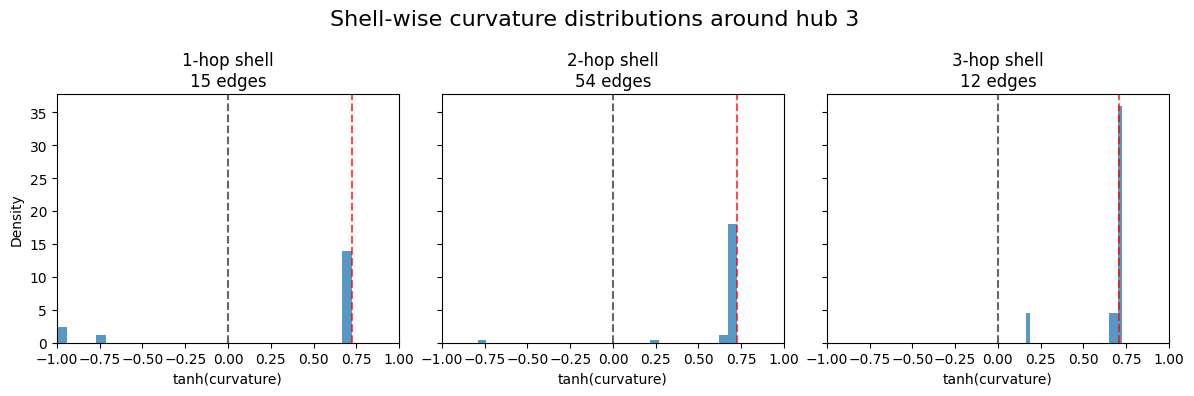

In [1076]:
# Normalize edge dict
edge_weight_dict = {
    tuple(sorted(edge)): w
    for edge, w in discrete_curvature_dict.items()
}

G = nx.Graph()
G.add_edges_from(edge_weight_dict.keys())

# -----------------------
# 1. Highest-degree node
# -----------------------
hub = max(G.degree, key=lambda x: x[1])[0]

# -----------------------
# 2. Extract shell-wise edge weights
# -----------------------
def shell_edge_weights(G, edge_weight_dict, center, max_hop):
    visited_edges = set()
    shell_weights = []

    for k in range(1, max_hop + 1):
        nodes_k = nx.single_source_shortest_path_length(G, center, cutoff=k).keys()
        subgraph = G.subgraph(nodes_k)

        current_edges = set(tuple(sorted(e)) for e in subgraph.edges())

        # Keep only new edges
        new_edges = current_edges - visited_edges
        visited_edges |= current_edges

        weights = np.array([
            edge_weight_dict[e] for e in new_edges
        ])

        weights = np.tanh(weights)

        shell_weights.append(weights)

    return shell_weights

# -----------------------
# 3. Plot
# -----------------------
max_hop = 3
shells = shell_edge_weights(G, edge_weight_dict, hub, max_hop)

fig, axes = plt.subplots(
    1, max_hop,
    figsize=(4 * max_hop, 4),
    sharex=True,
    sharey=True
)

for k, ax in enumerate(axes, start=1):
    weights_k = shells[k - 1]
    weights_k_median = np.median(weights_k) if len(weights_k) > 0 else 0

    if len(weights_k) > 0:
        ax.hist(weights_k, bins=30, density=True, alpha=0.75)
    else:
        ax.text(0.5, 0.5, "No edges", ha="center", va="center")

    ax.axvline(0, linestyle="--", color="black", alpha=0.6)
    ax.axvline(weights_k_median, linestyle="--", color="red", alpha=0.7, label=f"Median: {weights_k_median:.2f}")

    ax.set_title(f"{k}-hop shell\n{len(weights_k)} edges")
    ax.set_xlim(-1, 1)
    ax.set_xlabel("tanh(curvature)")

axes[0].set_ylabel("Density")

fig.suptitle(
    f"Shell-wise curvature distributions around hub {hub}",
    fontsize=16
)

plt.tight_layout()
plt.show()

## ? To-do List

Day ???:

1. Stesse visualizzazioni, ma usando i pesi
2. Variare sui pesi dei nodi, vedere come si distribuiscono
3. osservare come cambia il grafo visualizzato quando abbiamo diverse combinazioni di layer - layer massimo di diffusione
4. intuizione ML
5. carta e penna se c'è qualcosa di interessante

Day 24-06-2024:

1. TO-DO:
- implementare una funzione per la weighted Olliver-Ricci curvature, come riportato in "Discrete curvature on graphs from the effective resistance" (Lambiotte et al., 2024) - definizione (3)

2. DONE:
- trovare errore nella funzione generale che outputta sempre il graph di texas nel caso paper_Laplacian

## ?? Future Ideas

1. Analysis of ***Dirichlet energy*** on Graphs, given adjustable curvature